In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("/content/heart_disease.xlsx",sheet_name="Heart_disease")
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [3]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [5]:
df.dtypes

,0
age,int64
sex,object
cp,object
trestbps,int64
chol,int64
fbs,bool
restecg,object
thalch,int64
exang,object
oldpeak,float64


In [6]:
for col in df.columns:
    df[col] = df[col].replace({True: 1, False: 0}) #Convert true or false (bool) to integers

for col in df.columns:
    if df[col].dtype in ['int64','float64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0]) # Fill missing values

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str)                           # for label encoding

/tmp/ipython-input-3686707689.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({True: 1, False: 0}) #Convert true or false (bool) to integers


In [7]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [8]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    int64  
 2   cp        908 non-null    int64  
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    int64  
 6   restecg   908 non-null    int64  
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    int64  
 9   oldpeak   908 non-null    float64
 10  slope     908 non-null    int64  
 11  thal      908 non-null    int64  
 12  num       908 non-null    int64  
dtypes: float64(1), int64(12)
memory usage: 92.3 KB


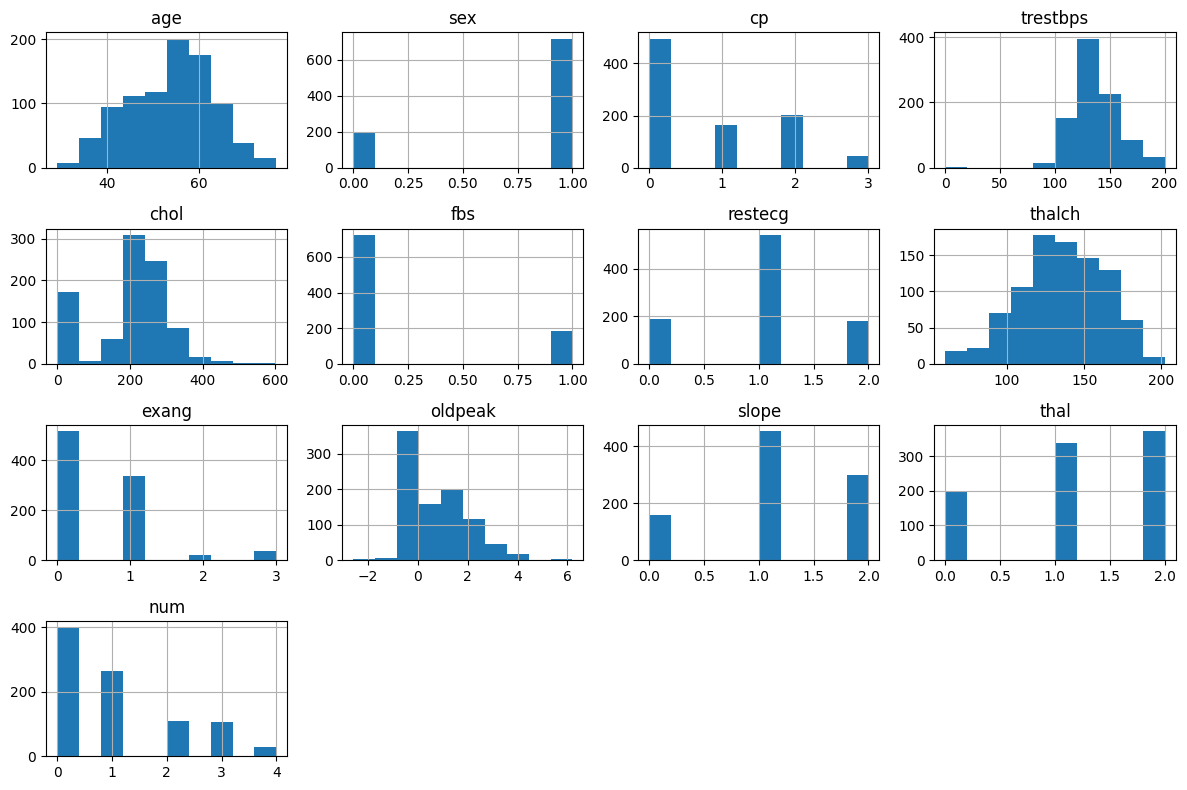

In [9]:
num_df = df.select_dtypes(include=['int64','float64'])
num_df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()


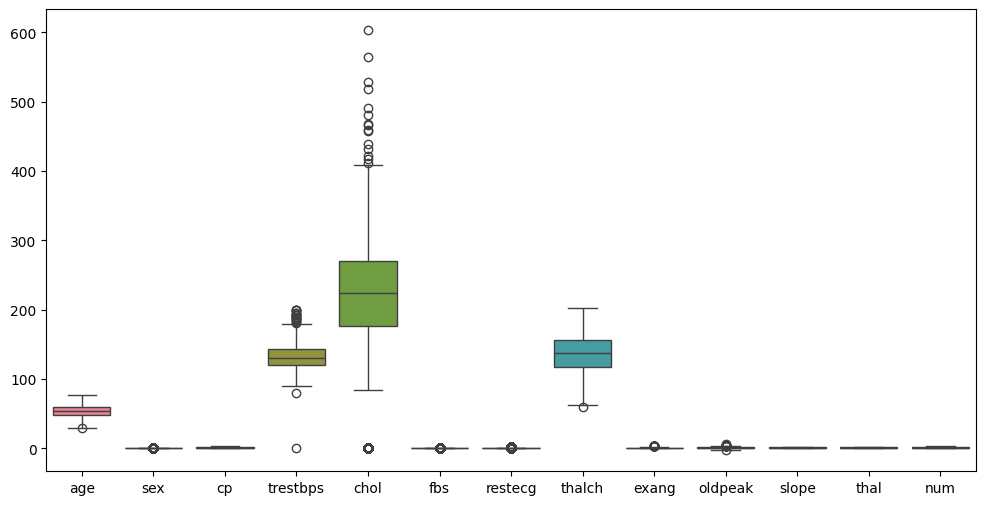

In [10]:
plt.figure(figsize=(12,6))
sns.boxplot(data=num_df)
plt.show()


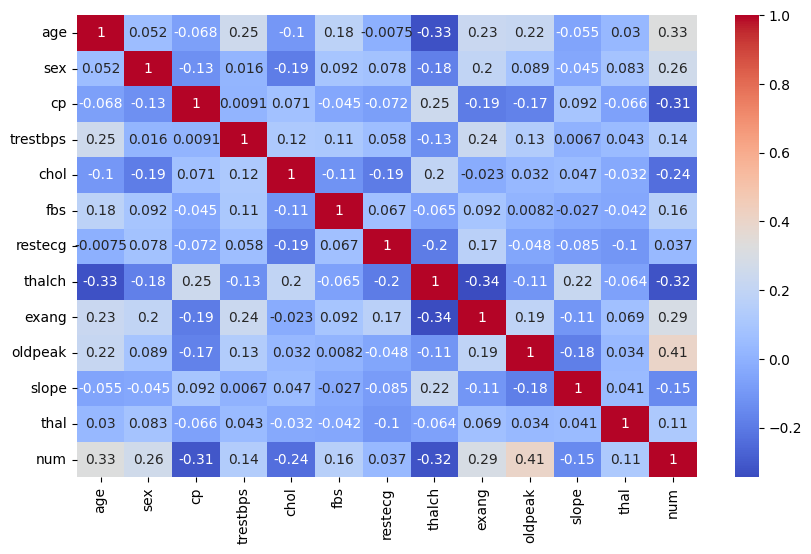

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.show()


In [12]:
X = df.drop("num", axis=1)
y = df["num"]


In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [15]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [16]:
y_pred = dt.predict(X_test)


In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5164835164835165

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.75      0.72        89
           1       0.39      0.38      0.38        48
           2       0.33      0.32      0.33        22
           3       0.15      0.12      0.13        17
           4       0.00      0.00      0.00         6

    accuracy                           0.52       182
   macro avg       0.32      0.31      0.31       182
weighted avg       0.50      0.52      0.51       182



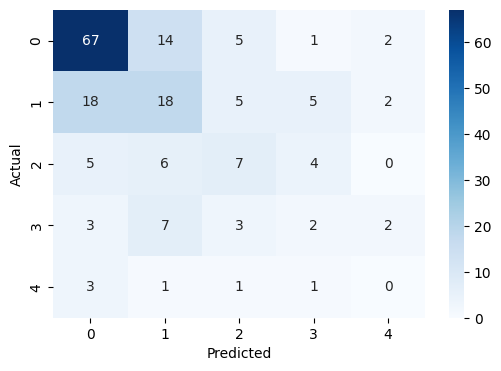

In [19]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [20]:
dt_tuned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    criterion='entropy',
    random_state=42
)
dt_tuned.fit(X_train, y_train)
y_pred_tuned = dt_tuned.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_tuned))


Tuned Accuracy: 0.5659340659340659


In [21]:
print("Before Tuning Accuracy:", accuracy_score(y_test, y_pred))
print("After Tuning Accuracy :", accuracy_score(y_test, y_pred_tuned))


Before Tuning Accuracy: 0.5164835164835165
After Tuning Accuracy : 0.5659340659340659


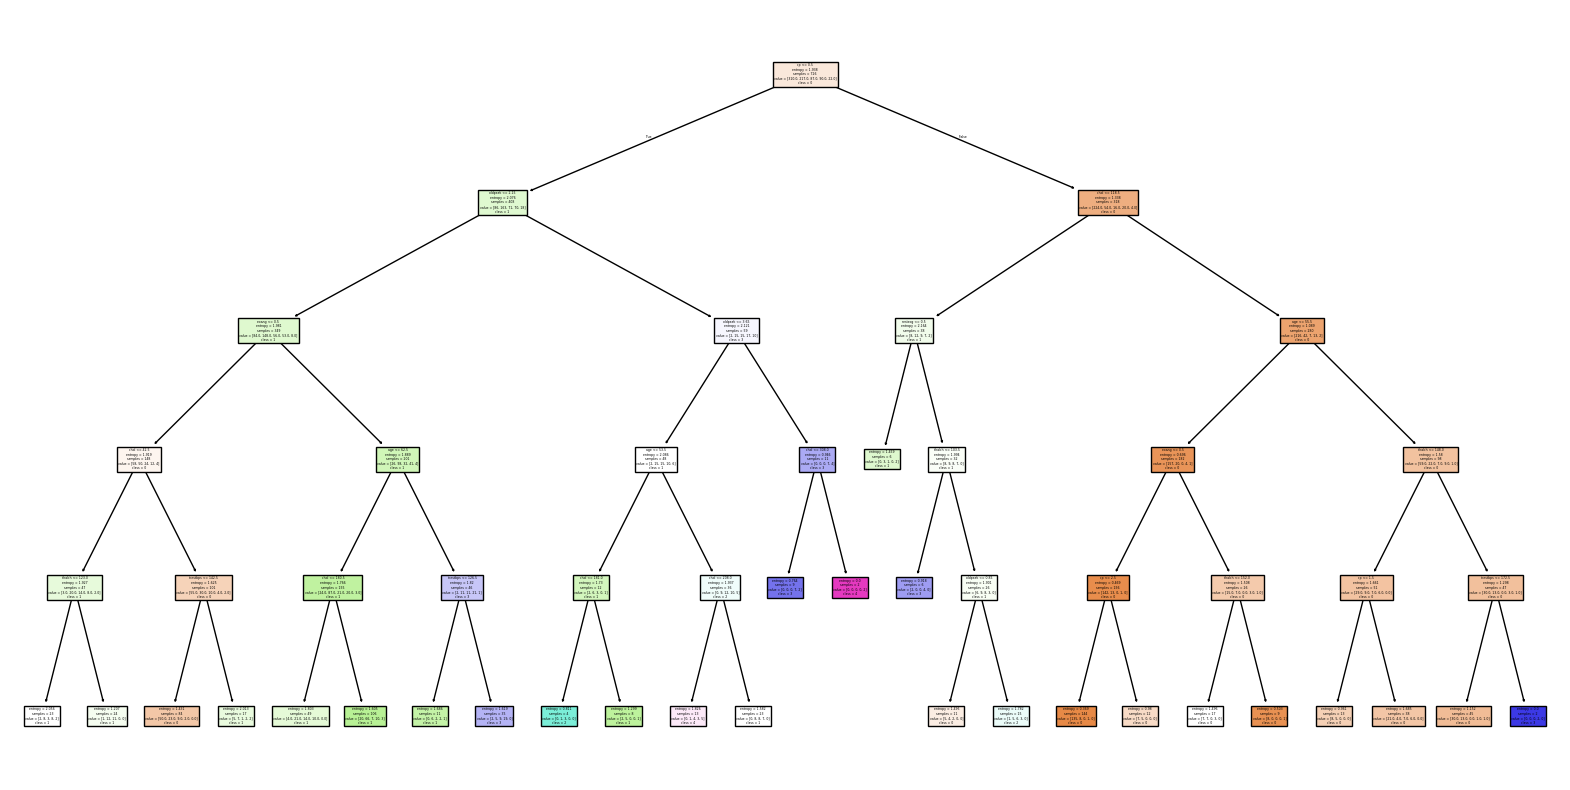

In [22]:
# Get unique target classes as strings
class_names = [str(c) for c in y.unique()]

plt.figure(figsize=(20,10))
plot_tree(dt_tuned,
          feature_names=X.columns,
          class_names=class_names,
          filled=True)
plt.show()


In [23]:
feature_imp = pd.Series(dt_tuned.feature_importances_, index=X.columns)
feature_imp.sort_values(ascending=False)


,0
cp,0.313605
chol,0.214334
age,0.114621
oldpeak,0.107031
exang,0.087093
thalch,0.086440
trestbps,0.056835
restecg,0.020041
sex,0.000000
fbs,0.000000


#**Interview Questions**

#1.Common Hyperparameters of Decision Tree ?



1.   max_depth – Maximum depth of tree
2.   min_samples_split – Minimum samples required to split a node
3.   min_samples_leaf – Minimum samples at a leaf node
4.   criterion – gini / entropy
5.   max_features – Number of features to consider when splitting








#2.Label Encoding vs One-Hot Encoding

1. Label Encoding: Converts categories to numbers (A=0, B=1)-> works for ordinal data
2. One-Hot Encoding: Creates a separate column for each category -> works for nominal data